In [28]:
# ==========================================================
# IMPORT REQUIRED LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np

import xgboost as xgb
import lightgbm as lgb

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [29]:
# ==========================================================
# CONFIGURATION
# ==========================================================

OEE_FILE = "data/oee-d.csv"
DOWN_FILE = "data/downtime.csv"

MODEL_TYPE = "xgb"

THRESHOLD = 0.6

LAG_DAYS = [1,3,7]
ROLL_WINDOWS = [3,7]

In [30]:
# ==========================================================
# HELPER FUNCTIONS
# ==========================================================

def risk_level(prob):

    if prob > 0.7:
        return "HIGH"

    elif prob > 0.4:
        return "MEDIUM"

    else:
        return "LOW"

In [31]:
# ==========================================================
# LOAD DATA
# ==========================================================

oee = pd.read_csv(OEE_FILE)
down = pd.read_csv(DOWN_FILE)

print("OEE Data Shape:", oee.shape)
print("Downtime Data Shape:", down.shape)

oee.head()

OEE Data Shape: (12409, 16)
Downtime Data Shape: (275973, 7)


,timestamp,MachineName,ProcessName,DivisionName,RunTime,DownTime,ProductionActual,ProductionRated,SpeedActual,SpeedRated,Availability,Performance,Quality,OEE,WeightActual,WeightRated
0,2025-07-01 07:00:00,DT1 4000 MM,Laying UP,UBR,7709,42392,2209.0,3160.09,15.74,24.55,15.39,69.90,100,10.76,0.00,0.00
1,2025-07-01 07:00:00,DT1 4000 MM,Laying UP,UBR,7281,9880,2043.0,2368.15,14.43,19.49,42.43,86.27,100,36.60,1569.08,1818.73
2,2025-07-01 07:00:00,Cu Tapping - C,Tapping,UBR,25785,60555,7218.1,0.00,16.69,0.00,29.86,0.00,100,0.00,0.00,0.00
3,2025-07-01 07:00:00,Sioplas MVCC 5,Insulation,UBR,0,8220,0.0,0.00,0.00,69.70,0.00,0.00,100,0.00,0.00,0.00
4,2025-07-01 07:00:00,Cu Tapping - F,Tapping,UBR,15634,70707,4381.6,0.00,15.03,0.00,18.11,0.00,100,0.00,0.00,0.00


In [32]:
# ==========================================================
# DATA CLEANING
# ==========================================================

# Convert timestamps

oee['timestamp'] = pd.to_datetime(oee['timestamp'])
down['FromTime'] = pd.to_datetime(down['FromTime'])
down['ToTime'] = pd.to_datetime(down['ToTime'])

# Extract Date

oee['Date'] = oee['timestamp'].dt.date
down['Date'] = down['FromTime'].dt.date

# Machine names

oee['MachineName'] = oee['MachineName'].str.strip()
down['MachineName'] = down['MachineName'].str.strip()

# Fill missing reason

down['Reason'] = down['Reason'].fillna("Unknown")

oee.head()

,timestamp,MachineName,ProcessName,DivisionName,RunTime,DownTime,ProductionActual,ProductionRated,SpeedActual,SpeedRated,Availability,Performance,Quality,OEE,WeightActual,WeightRated,Date
0,2025-07-01 07:00:00,DT1 4000 MM,Laying UP,UBR,7709,42392,2209.0,3160.09,15.74,24.55,15.39,69.90,100,10.76,0.00,0.00,2025-07-01
1,2025-07-01 07:00:00,DT1 4000 MM,Laying UP,UBR,7281,9880,2043.0,2368.15,14.43,19.49,42.43,86.27,100,36.60,1569.08,1818.73,2025-07-01
2,2025-07-01 07:00:00,Cu Tapping - C,Tapping,UBR,25785,60555,7218.1,0.00,16.69,0.00,29.86,0.00,100,0.00,0.00,0.00,2025-07-01
3,2025-07-01 07:00:00,Sioplas MVCC 5,Insulation,UBR,0,8220,0.0,0.00,0.00,69.70,0.00,0.00,100,0.00,0.00,0.00,2025-07-01
4,2025-07-01 07:00:00,Cu Tapping - F,Tapping,UBR,15634,70707,4381.6,0.00,15.03,0.00,18.11,0.00,100,0.00,0.00,0.00,2025-07-01


In [33]:
# ==========================================================
# DAILY DATASET
# ==========================================================

daily_oee = oee.groupby(['MachineName','Date']).agg(

    RunTime=('RunTime','sum'),
    DownTime=('DownTime','sum'),

    ProductionActual=('ProductionActual','sum'),
    ProductionRated=('ProductionRated','sum'),

    SpeedActual=('SpeedActual','mean'),
    SpeedRated=('SpeedRated','mean'),

    OEE=('OEE','mean')

).reset_index()


down_daily = down.groupby(['MachineName','Date']).agg(

    Daily_Downtime=('TotalTime','sum'),
    Stop_Count=('TotalTime','size')

).reset_index()

daily_df = daily_oee.merge(down_daily,on=['MachineName','Date'],how='left')

daily_df[['Daily_Downtime','Stop_Count']] = daily_df[['Daily_Downtime','Stop_Count']].fillna(0)

daily_df.head()

,MachineName,Date,RunTime,DownTime,ProductionActual,ProductionRated,SpeedActual,SpeedRated,OEE,Daily_Downtime,Stop_Count
0,120 MM Ext U3,2025-07-01,117844,54836,12372.2,18010.54,4.280000,7.600000,31.873333,29927.0,23.0
1,120 MM Ext U3,2025-07-02,105166,67516,42791.6,48127.10,17.102500,20.892500,42.017500,33556.0,18.0
2,120 MM Ext U3,2025-07-03,83908,88774,35621.6,41436.08,25.190000,29.630000,41.770000,24092.0,11.0
3,120 MM Ext U3,2025-07-04,73788,98894,29456.0,36465.16,23.730000,29.630000,34.520000,49138.0,9.0
4,120 MM Ext U3,2025-07-05,39208,133472,12567.6,25311.04,12.633333,35.366667,7.963333,64009.0,7.0


In [34]:
# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

daily_df = daily_df.sort_values(['MachineName','Date'])


features = [

    'OEE','RunTime','DownTime',
    'ProductionActual','ProductionRated',
    'SpeedActual','SpeedRated',
    'Daily_Downtime','Stop_Count'

]


for feat in features:

    for lag in LAG_DAYS:

        daily_df[f"{feat}_lag{lag}"] = daily_df.groupby('MachineName')[feat].shift(lag)



for feat in ['RunTime','DownTime','OEE','Daily_Downtime','Stop_Count']:

    for window in ROLL_WINDOWS:

        daily_df[f"{feat}_rollmean_{window}"] = daily_df.groupby('MachineName')[feat].transform(
            lambda x: x.rolling(window).mean()
        )

        daily_df[f"{feat}_rollstd_{window}"] = daily_df.groupby('MachineName')[feat].transform(
            lambda x: x.rolling(window).std()
        )


daily_df['Stop_3day'] = daily_df.groupby('MachineName')['Stop_Count'].transform(
    lambda x: x.rolling(3).sum()
)

daily_df.head()

,MachineName,Date,RunTime,DownTime,ProductionActual,ProductionRated,SpeedActual,SpeedRated,OEE,Daily_Downtime,...,OEE_rollstd_7,Daily_Downtime_rollmean_3,Daily_Downtime_rollstd_3,Daily_Downtime_rollmean_7,Daily_Downtime_rollstd_7,Stop_Count_rollmean_3,Stop_Count_rollstd_3,Stop_Count_rollmean_7,Stop_Count_rollstd_7,Stop_3day
0,120 MM Ext U3,2025-07-01,117844,54836,12372.2,18010.54,4.280000,7.600000,31.873333,29927.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,120 MM Ext U3,2025-07-02,105166,67516,42791.6,48127.10,17.102500,20.892500,42.017500,33556.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,120 MM Ext U3,2025-07-03,83908,88774,35621.6,41436.08,25.190000,29.630000,41.770000,24092.0,...,NaN,29191.666667,4774.658138,NaN,NaN,17.333333,6.027714,NaN,NaN,52.0
3,120 MM Ext U3,2025-07-04,73788,98894,29456.0,36465.16,23.730000,29.630000,34.520000,49138.0,...,NaN,35595.333333,12646.924106,NaN,NaN,12.666667,4.725816,NaN,NaN,38.0
4,120 MM Ext U3,2025-07-05,39208,133472,12567.6,25311.04,12.633333,35.366667,7.963333,64009.0,...,NaN,45746.333333,20173.479480,NaN,NaN,9.000000,2.000000,NaN,NaN,27.0


In [35]:
# ==========================================================
# CREATE TARGET
# ==========================================================

daily_df['Current_Degrading'] = np.where(

    (daily_df['OEE'] < 70) &
    (daily_df['Daily_Downtime'] / (daily_df['RunTime'] + daily_df['Daily_Downtime']) > 0.25),

    1,0
)

daily_df['Target'] = daily_df.groupby('MachineName')['Current_Degrading'].shift(-1)

daily_df = daily_df.dropna(subset=['Target'])

daily_df.head()

,MachineName,Date,RunTime,DownTime,ProductionActual,ProductionRated,SpeedActual,SpeedRated,OEE,Daily_Downtime,...,Daily_Downtime_rollstd_3,Daily_Downtime_rollmean_7,Daily_Downtime_rollstd_7,Stop_Count_rollmean_3,Stop_Count_rollstd_3,Stop_Count_rollmean_7,Stop_Count_rollstd_7,Stop_3day,Current_Degrading,Target
0,120 MM Ext U3,2025-07-01,117844,54836,12372.2,18010.54,4.280000,7.600000,31.873333,29927.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0
1,120 MM Ext U3,2025-07-02,105166,67516,42791.6,48127.10,17.102500,20.892500,42.017500,33556.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0
2,120 MM Ext U3,2025-07-03,83908,88774,35621.6,41436.08,25.190000,29.630000,41.770000,24092.0,...,4774.658138,NaN,NaN,17.333333,6.027714,NaN,NaN,52.0,0,1.0
3,120 MM Ext U3,2025-07-04,73788,98894,29456.0,36465.16,23.730000,29.630000,34.520000,49138.0,...,12646.924106,NaN,NaN,12.666667,4.725816,NaN,NaN,38.0,1,1.0
4,120 MM Ext U3,2025-07-05,39208,133472,12567.6,25311.04,12.633333,35.366667,7.963333,64009.0,...,20173.479480,NaN,NaN,9.000000,2.000000,NaN,NaN,27.0,1,1.0


In [36]:
# ==========================================================
# LABEL ENCODING
# ==========================================================

le = LabelEncoder()

daily_df['MachineID'] = le.fit_transform(daily_df['MachineName'])

In [37]:
# ==========================================================
# TIME BASED SPLIT
# ==========================================================

feature_cols = [col for col in daily_df.columns if ('lag' in col or 'roll' in col)]

feature_cols.append("MachineID")

split_date = daily_df['Date'].quantile(0.8)

train_df = daily_df[daily_df['Date'] <= split_date]
test_df = daily_df[daily_df['Date'] > split_date]

X_train = train_df[feature_cols]
y_train = train_df['Target']

X_test = test_df[feature_cols]
y_test = test_df['Target']

print(X_train.shape)
print(X_test.shape)

(3429, 48)
(853, 48)


In [38]:
# ==========================================================
# TRAIN MODEL
# ==========================================================

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = xgb.XGBClassifier(

    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"

)

model.fit(X_train,y_train)

print("Model Training Completed")

Model Training Completed


In [39]:
# ==========================================================
# MODEL EVALUATION
# ==========================================================

y_prob = model.predict_proba(X_test)[:,1]

y_pred = (y_prob > THRESHOLD).astype(int)

print("Accuracy:",accuracy_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy: 0.8862837045720985
              precision    recall  f1-score   support

         0.0       0.80      0.94      0.87       335
         1.0       0.96      0.85      0.90       518

    accuracy                           0.89       853
   macro avg       0.88      0.90      0.88       853
weighted avg       0.90      0.89      0.89       853



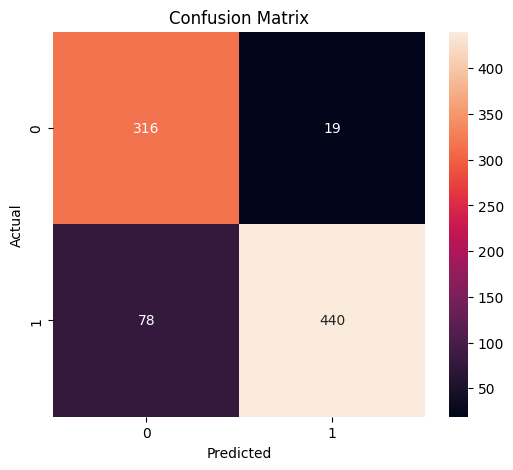


Confusion Matrix:
 [[316  19]
 [ 78 440]]


In [40]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")
plt.show()
print("\nConfusion Matrix:\n", cm)

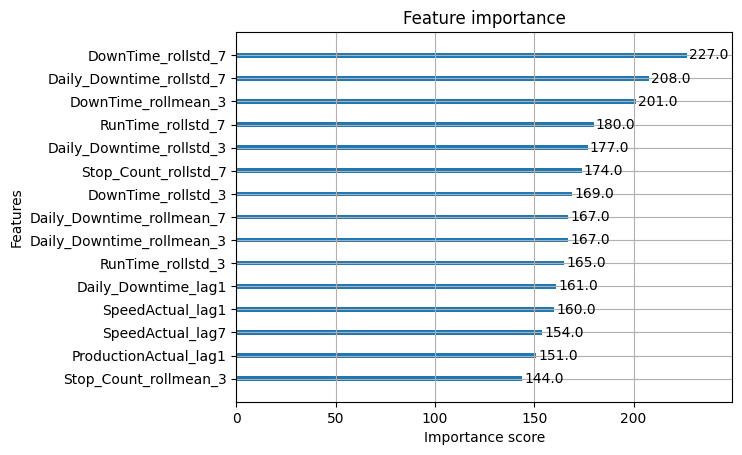

In [41]:
xgb.plot_importance(model,max_num_features=15)

plt.show()

In [42]:
# ==========================================================
# MACHINE HEALTH
# ==========================================================

results = test_df[['MachineName','Date']].copy()

results["Degradation_Probability"] = y_prob.round(4)

results["Health_Score"] = ((1 - y_prob) * 100).round(2)

results["Risk_Level"] = [risk_level(p) for p in y_prob]

# Latest machine status
results = results.sort_values("Date")

results = results.groupby("MachineName").tail(1)

# Priority machines first
results = results.sort_values("Health_Score")

results.head(10)

,MachineName,Date,Degradation_Probability,Health_Score,Risk_Level
1828,Cu Tapping - B,2025-12-30,0.9991,0.09,HIGH
2359,Cu Tapping - E,2025-12-30,0.9989,0.11,HIGH
2825,DT1 4000 MM,2025-12-30,0.9989,0.11,HIGH
1296,72B ARMORING U4,2025-12-30,0.9988,0.12,HIGH
1467,72B ARMORING U2,2025-12-30,0.9981,0.19,HIGH
2000,Cu Tapping - C,2025-12-30,0.9973,0.27,HIGH
2651,Cu Tapping - G,2025-12-09,0.9956,0.44,HIGH
2539,Cu Tapping - F,2025-12-30,0.9952,0.48,HIGH
2181,Cu Tapping - D,2025-12-30,0.9940,0.60,HIGH
2862,DT3 3200 MM,2025-12-30,0.9903,0.97,HIGH


In [43]:
# ==========================================================
# OPERATOR SUGGESTIONS
# ==========================================================

def operator_action(row):

    if row["Risk_Level"] == "HIGH":
        return "Check machine cleaning, lubrication and alignment"

    elif row["Risk_Level"] == "MEDIUM":
        return "Monitor machine speed and minor stoppages"

    else:
        return "Machine running normal"


results["Operator_Action"] = results.apply(operator_action,axis=1)

In [44]:
# ==========================================================
# SHIFT INCHARGE ACTION
# ==========================================================

def shift_action(row):

    if row["Risk_Level"] == "HIGH":
        return "Plan maintenance before next shift"

    elif row["Risk_Level"] == "MEDIUM":
        return "Monitor performance and reduce minor stops"

    else:
        return "No action required"


results["Shift_Incharge_Action"] = results.apply(shift_action,axis=1)

In [45]:
# ==========================================================
# MANAGER ACTION
# ==========================================================

def manager_action(row):

    if row["Risk_Level"] == "HIGH":
        return "Schedule preventive maintenance"

    elif row["Risk_Level"] == "MEDIUM":
        return "Investigate root cause of downtime"

    else:
        return "Production stable"


results["Manager_Action"] = results.apply(manager_action,axis=1)

In [46]:
results.head(20)

,MachineName,Date,Degradation_Probability,Health_Score,Risk_Level,Operator_Action,Shift_Incharge_Action,Manager_Action
1828,Cu Tapping - B,2025-12-30,0.9991,0.090000,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2359,Cu Tapping - E,2025-12-30,0.9989,0.110000,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2825,DT1 4000 MM,2025-12-30,0.9989,0.110000,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
1296,72B ARMORING U4,2025-12-30,0.9988,0.120000,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
1467,72B ARMORING U2,2025-12-30,0.9981,0.190000,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2000,Cu Tapping - C,2025-12-30,0.9973,0.270000,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2651,Cu Tapping - G,2025-12-09,0.9956,0.440000,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2539,Cu Tapping - F,2025-12-30,0.9952,0.480000,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2181,Cu Tapping - D,2025-12-30,0.9940,0.600000,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2862,DT3 3200 MM,2025-12-30,0.9903,0.970000,HIGH,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance


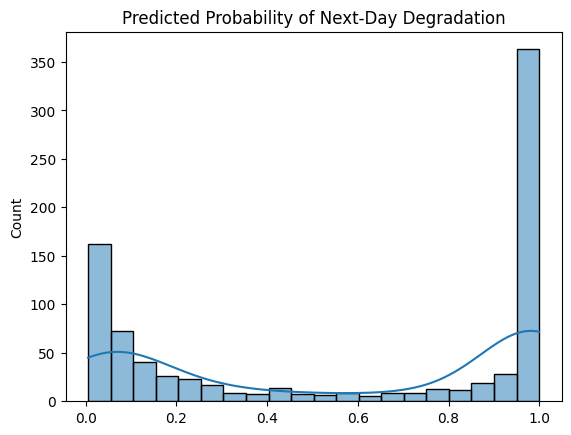

In [47]:
# =====================================================
# PROBABILITY DISTRIBUTION
# =====================================================

sns.histplot(y_prob, bins=20, kde=True)

plt.title("Predicted Probability of Next-Day Degradation")

plt.show()

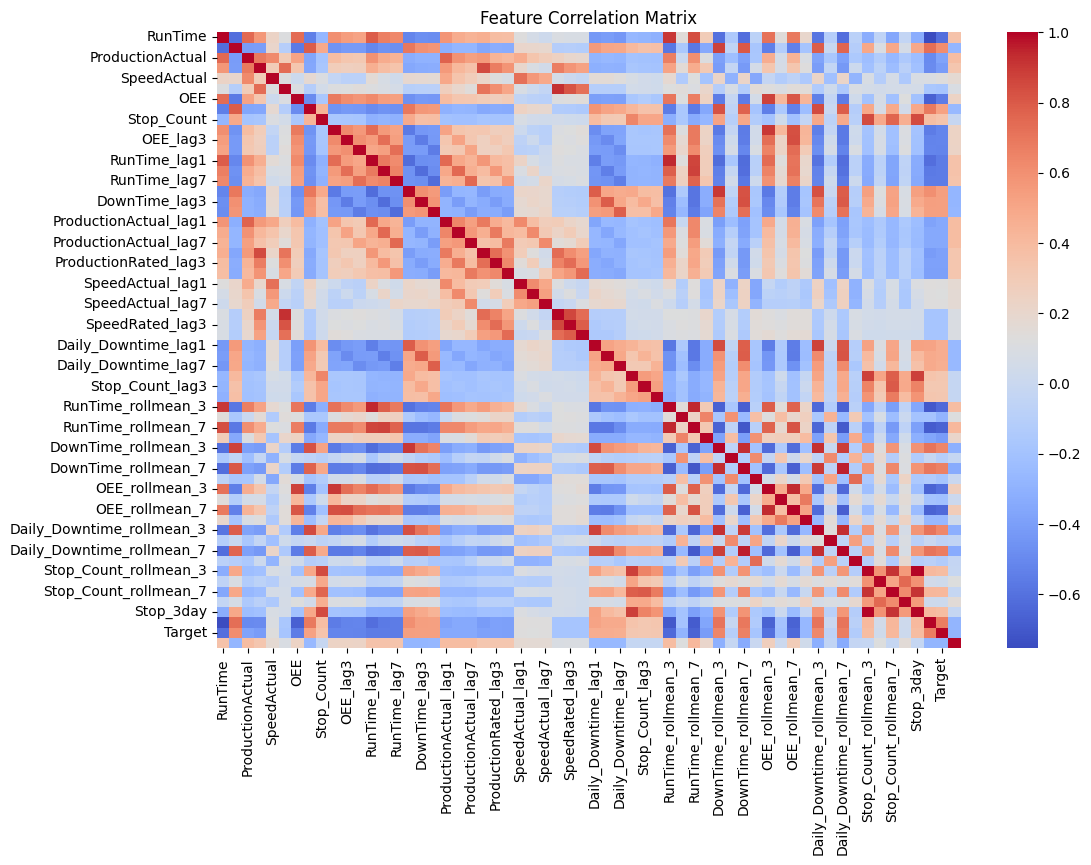

In [48]:
# =====================================================
# FEATURE CORRELATION
# =====================================================

corr_matrix = daily_df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix, cmap='coolwarm')

plt.title("Feature Correlation Matrix")

plt.show()

In [49]:
# =====================================================
# PRINT HIGH RISK MACHINES
# =====================================================

for _, row in results.head(10).iterrows():

    print(f"""
Machine: {row['MachineName']}
Health Score: {row['Health_Score']:.2f}
Risk Level: {row['Risk_Level']}
----------------------------
""")


Machine: Cu Tapping - B
Health Score: 0.09
Risk Level: HIGH
----------------------------


Machine: Cu Tapping - E
Health Score: 0.11
Risk Level: HIGH
----------------------------


Machine: DT1  4000 MM
Health Score: 0.11
Risk Level: HIGH
----------------------------


Machine: 72B ARMORING  U4
Health Score: 0.12
Risk Level: HIGH
----------------------------


Machine: 72B ARMORING U2
Health Score: 0.19
Risk Level: HIGH
----------------------------


Machine: Cu Tapping - C
Health Score: 0.27
Risk Level: HIGH
----------------------------


Machine: Cu Tapping - G
Health Score: 0.44
Risk Level: HIGH
----------------------------


Machine: Cu Tapping - F
Health Score: 0.48
Risk Level: HIGH
----------------------------


Machine: Cu Tapping - D
Health Score: 0.60
Risk Level: HIGH
----------------------------


Machine: DT3  3200 MM
Health Score: 0.97
Risk Level: HIGH
----------------------------



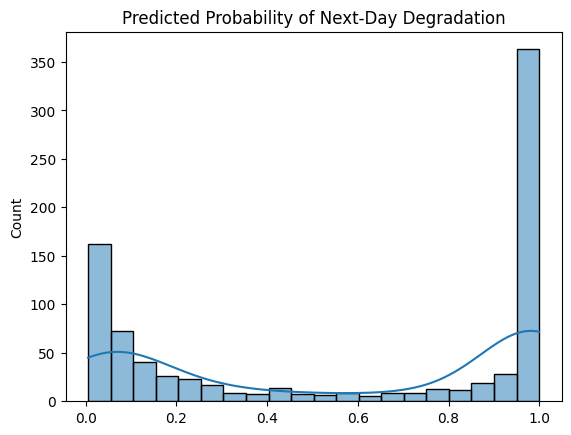

In [50]:
sns.histplot(y_prob, bins=20, kde=True)

plt.title("Predicted Probability of Next-Day Degradation")

plt.show()

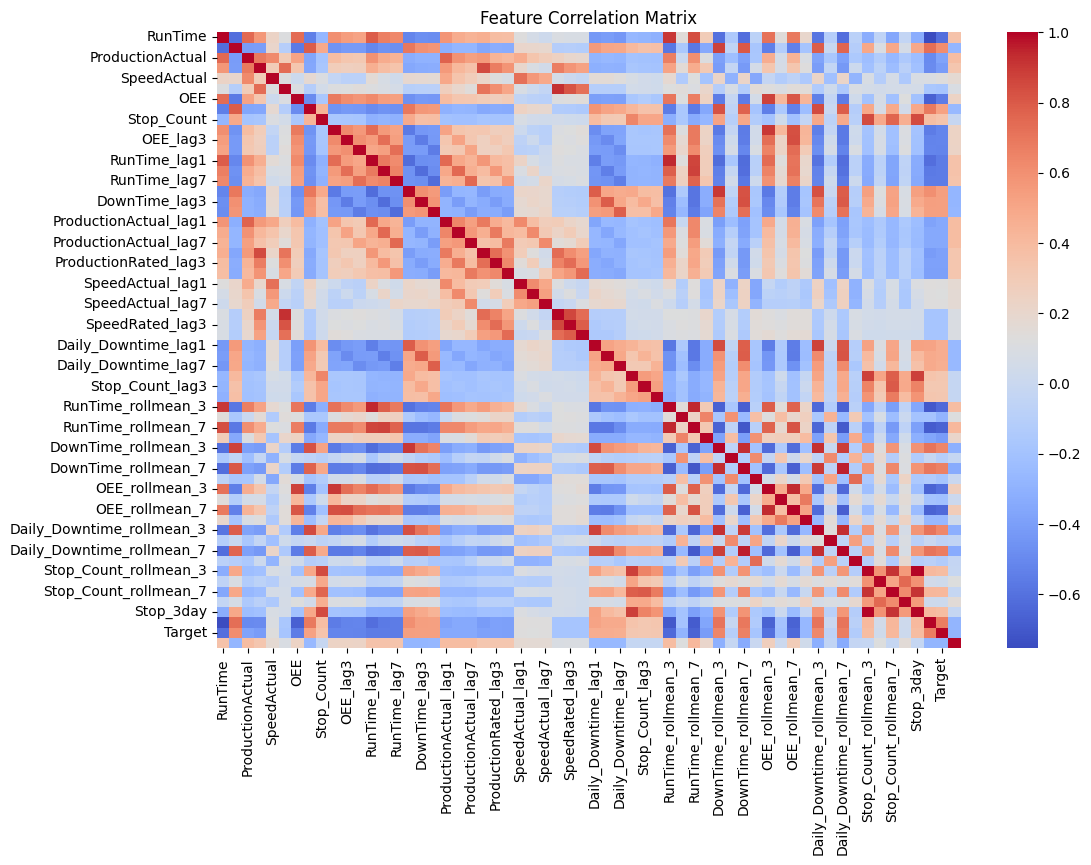

In [51]:
corr_matrix = daily_df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm')

plt.title("Feature Correlation Matrix")

plt.show()

In [52]:
# from sklearn.model_selection import TimeSeriesSplit

# tscv = TimeSeriesSplit(n_splits=5)
# for train_idx, val_idx in tscv.split(X_train):
#     X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
#     y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
#     model.fit(X_tr, y_tr)
#     y_pred = model.predict(X_val)
#     print(classification_report(y_val, y_pred))

In [53]:
daily_df.head()

,MachineName,Date,RunTime,DownTime,ProductionActual,ProductionRated,SpeedActual,SpeedRated,OEE,Daily_Downtime,...,Daily_Downtime_rollmean_7,Daily_Downtime_rollstd_7,Stop_Count_rollmean_3,Stop_Count_rollstd_3,Stop_Count_rollmean_7,Stop_Count_rollstd_7,Stop_3day,Current_Degrading,Target,MachineID
0,120 MM Ext U3,2025-07-01,117844,54836,12372.2,18010.54,4.280000,7.600000,31.873333,29927.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,0
1,120 MM Ext U3,2025-07-02,105166,67516,42791.6,48127.10,17.102500,20.892500,42.017500,33556.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0,0
2,120 MM Ext U3,2025-07-03,83908,88774,35621.6,41436.08,25.190000,29.630000,41.770000,24092.0,...,NaN,NaN,17.333333,6.027714,NaN,NaN,52.0,0,1.0,0
3,120 MM Ext U3,2025-07-04,73788,98894,29456.0,36465.16,23.730000,29.630000,34.520000,49138.0,...,NaN,NaN,12.666667,4.725816,NaN,NaN,38.0,1,1.0,0
4,120 MM Ext U3,2025-07-05,39208,133472,12567.6,25311.04,12.633333,35.366667,7.963333,64009.0,...,NaN,NaN,9.000000,2.000000,NaN,NaN,27.0,1,1.0,0


In [54]:
daily_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4282 entries, 0 to 4309
Data columns (total 62 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   MachineName                4282 non-null   object 
 1   Date                       4282 non-null   object 
 2   RunTime                    4282 non-null   int64  
 3   DownTime                   4282 non-null   int64  
 4   ProductionActual           4282 non-null   float64
 5   ProductionRated            4282 non-null   float64
 6   SpeedActual                4282 non-null   float64
 7   SpeedRated                 4282 non-null   float64
 8   OEE                        4282 non-null   float64
 9   Daily_Downtime             4282 non-null   float64
 10  Stop_Count                 4282 non-null   float64
 11  OEE_lag1                   4254 non-null   float64
 12  OEE_lag3                   4198 non-null   float64
 13  OEE_lag7                   4086 non-null   float64
 1

In [55]:
# ======================================================
# CHECK TARGET DISTRIBUTION
# ======================================================

daily_df["Target"].value_counts()

Target
1.0    2708
0.0    1574
Name: count, dtype: int64

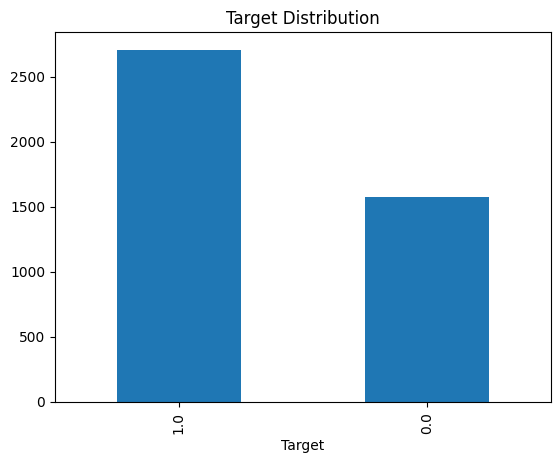

In [56]:
daily_df["Target"].value_counts().plot(kind="bar")

plt.title("Target Distribution")
plt.show()

In [57]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.80      0.94      0.87       335
         1.0       0.96      0.85      0.90       518

    accuracy                           0.89       853
   macro avg       0.88      0.90      0.88       853
weighted avg       0.90      0.89      0.89       853



In [58]:
check_df = test_df[['MachineName','Date']].copy()

check_df["Actual"] = y_test.values
check_df["Predicted"] = y_pred
check_df["Probability"] = y_prob

check_df.head(20)

,MachineName,Date,Actual,Predicted,Probability
138,120 MM Ext U3,2025-11-28,1.0,0,0.564690
139,120 MM Ext U3,2025-11-29,0.0,0,0.428556
140,120 MM Ext U3,2025-11-30,1.0,0,0.072629
141,120 MM Ext U3,2025-12-01,1.0,1,0.615079
142,120 MM Ext U3,2025-12-02,1.0,0,0.291402
143,120 MM Ext U3,2025-12-03,1.0,0,0.426298
144,120 MM Ext U3,2025-12-04,1.0,1,0.785323
145,120 MM Ext U3,2025-12-05,1.0,0,0.557263
146,120 MM Ext U3,2025-12-06,1.0,1,0.729607
147,120 MM Ext U3,2025-12-07,1.0,0,0.457068


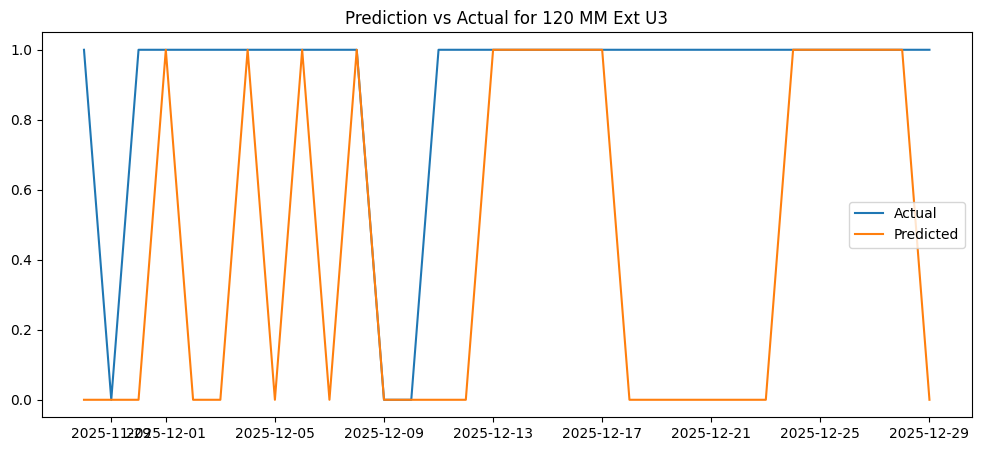

In [59]:
machine = check_df["MachineName"].iloc[0]

machine_df = check_df[check_df["MachineName"] == machine]

plt.figure(figsize=(12,5))

plt.plot(machine_df["Date"], machine_df["Actual"], label="Actual")

plt.plot(machine_df["Date"], machine_df["Predicted"], label="Predicted")

plt.legend()

plt.title(f"Prediction vs Actual for {machine}")

plt.show()

In [60]:
importance = pd.DataFrame({

"Feature":feature_cols,
"Importance":model.feature_importances_

}).sort_values("Importance",ascending=False)

importance.head(20)

,Feature,Importance
29,RunTime_rollmean_7,0.208103
41,Daily_Downtime_rollmean_7,0.158792
39,Daily_Downtime_rollmean_3,0.077841
43,Stop_Count_rollmean_3,0.043570
47,MachineID,0.041020
27,RunTime_rollmean_3,0.038457
31,DownTime_rollmean_3,0.036959
30,RunTime_rollstd_7,0.018953
35,OEE_rollmean_3,0.016999
28,RunTime_rollstd_3,0.015385


In [61]:
train_pred = model.predict(X_train)

print("Train Accuracy:",accuracy_score(y_train,train_pred))
print("Test Accuracy:",accuracy_score(y_test,y_pred))

Train Accuracy: 0.9731700204141149
Test Accuracy: 0.8862837045720985


In [62]:
np.random.seed(42)

sample = check_df.sample(20)

sample

,MachineName,Date,Actual,Predicted,Probability
439,150 Covema,2025-12-02,0.0,0,0.052631
2352,Cu Tapping - E,2025-12-23,1.0,1,0.999122
1096,54 Armouring,2025-12-08,1.0,1,0.973547
1110,54 Armouring,2025-12-22,1.0,1,0.943333
3480,SioPlas U3,2025-12-28,0.0,0,0.020151
3007,Drum twister(DT)-2,2025-12-08,1.0,1,0.999236
1464,72B ARMORING U2,2025-12-27,1.0,1,0.988580
1626,CCV Sloze U4,2025-12-10,1.0,0,0.040251
1990,Cu Tapping - C,2025-12-20,1.0,1,0.998987
3637,SioPlas U4,2025-12-22,0.0,1,0.600123


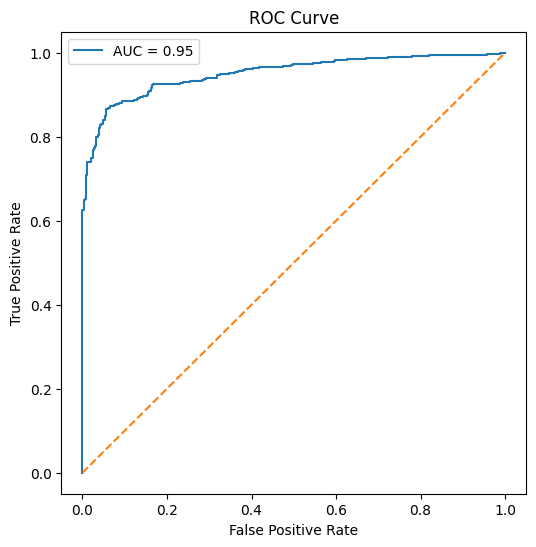

In [63]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

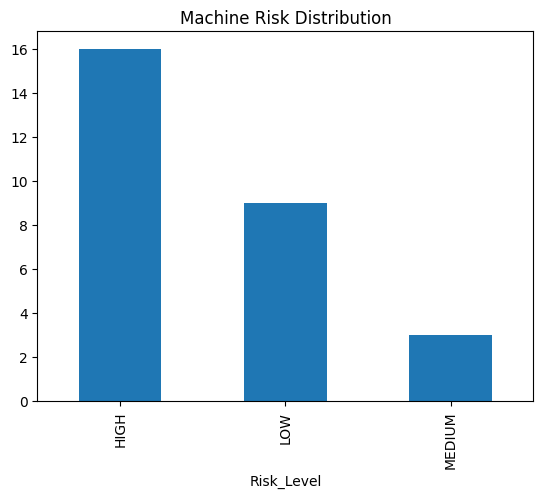

In [64]:
results["Risk_Level"].value_counts().plot(kind="bar")

plt.title("Machine Risk Distribution")

plt.show()

In [65]:
# ======================================================
# FINAL DASHBOARD TABLE
# ======================================================

final_table = results[[
    
    "MachineName",
    "Risk_Level",
    "Health_Score",
    "Operator_Action",
    "Shift_Incharge_Action",
    "Manager_Action"
]]

final_table.head(20)

,MachineName,Risk_Level,Health_Score,Operator_Action,Shift_Incharge_Action,Manager_Action
1828,Cu Tapping - B,HIGH,0.090000,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2359,Cu Tapping - E,HIGH,0.110000,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2825,DT1 4000 MM,HIGH,0.110000,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
1296,72B ARMORING U4,HIGH,0.120000,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
1467,72B ARMORING U2,HIGH,0.190000,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2000,Cu Tapping - C,HIGH,0.270000,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2651,Cu Tapping - G,HIGH,0.440000,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2539,Cu Tapping - F,HIGH,0.480000,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2181,Cu Tapping - D,HIGH,0.600000,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2862,DT3 3200 MM,HIGH,0.970000,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance


In [66]:
top_risk = final_table.sort_values("Health_Score")

top_risk.head(10)

,MachineName,Risk_Level,Health_Score,Operator_Action,Shift_Incharge_Action,Manager_Action
1828,Cu Tapping - B,HIGH,0.09,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2359,Cu Tapping - E,HIGH,0.11,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2825,DT1 4000 MM,HIGH,0.11,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
1296,72B ARMORING U4,HIGH,0.12,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
1467,72B ARMORING U2,HIGH,0.19,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2000,Cu Tapping - C,HIGH,0.27,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2651,Cu Tapping - G,HIGH,0.44,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2539,Cu Tapping - F,HIGH,0.48,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2181,Cu Tapping - D,HIGH,0.60,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance
2862,DT3 3200 MM,HIGH,0.97,"Check machine cleaning, lubrication and alignment",Plan maintenance before next shift,Schedule preventive maintenance


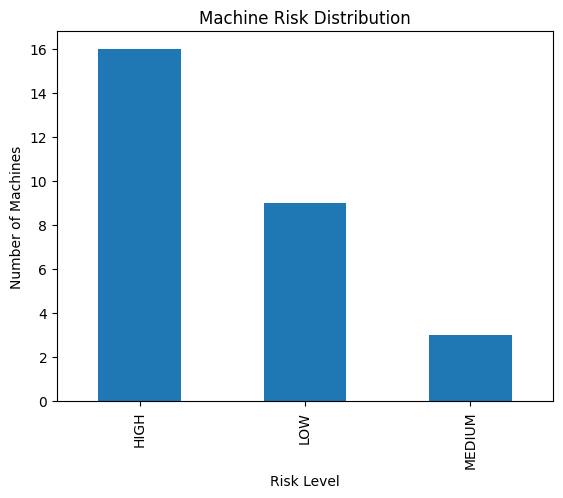

In [67]:
results["Risk_Level"].value_counts().plot(kind="bar")

plt.title("Machine Risk Distribution")

plt.xlabel("Risk Level")

plt.ylabel("Number of Machines")

plt.show()

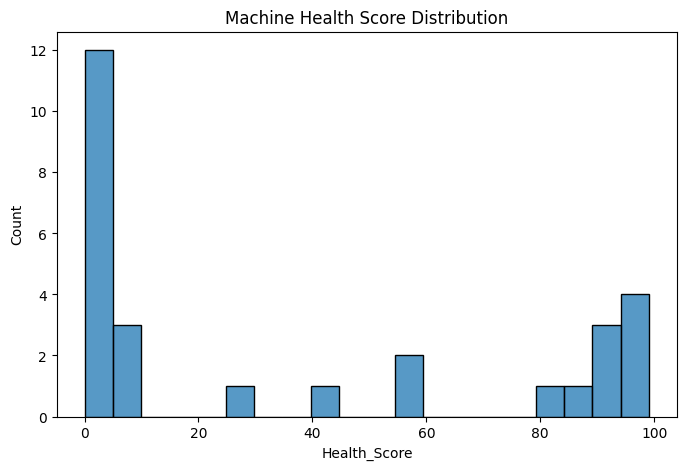

In [68]:
plt.figure(figsize=(8,5))

sns.histplot(results["Health_Score"], bins=20)

plt.title("Machine Health Score Distribution")

plt.show()

In [69]:
final_table.to_csv("machine_health_report.csv", index=False)

In [70]:
import joblib

joblib.dump(model,"model.pkl")

['model.pkl']